In [2]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

# 5. i)

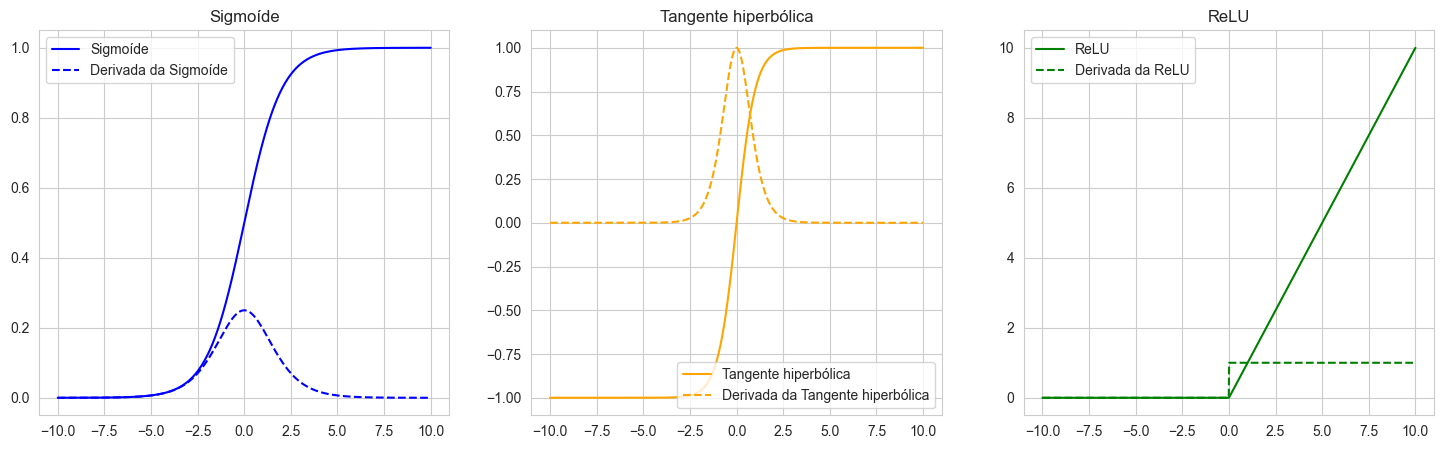

In [46]:
# Plot sigmoid, tanh, and ReLU activation functions (and their respective derivatives):
x = np.linspace(-10, 10, 1000)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

# derivatives
sigmoid_derivative = sigmoid * (1 - sigmoid)
tanh_derivative = 1 - tanh**2
relu_derivative = np.where(x > 0, 1, 0)

# plot it using subplots with the activation functions and their derivatives on the same plot:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sigmoid
axes[0].plot(x, sigmoid, label='Sigmoíde', color='blue')
axes[0].plot(x, sigmoid_derivative, label='Derivada da Sigmoíde', color='blue', linestyle='--')
axes[0].set_title('Sigmoíde')
axes[0].legend()

# Tanh
axes[1].plot(x, tanh, label='Tangente hiperbólica', color='orange')
axes[1].plot(x, tanh_derivative, label='Derivada da Tangente hiperbólica', color='orange', linestyle='--')
axes[1].set_title('Tangente hiperbólica')
axes[1].legend()

# ReLU
axes[2].plot(x, relu, label='ReLU', color='green')
axes[2].plot(x, relu_derivative, label='Derivada da ReLU', color='green', linestyle='--')
axes[2].set_title('ReLU')
axes[2].legend()

plt.show()

# MLP Setup

To add:
- early stopping 
- check improvements (we don't care for models that take us from 8e-4 to 2e-4)

In [6]:
class MLP(torch.nn.Module):
    """
    Generic Multi-Layer Perceptron (MLP) implementation in PyTorch.
    """
    def __init__(
        self, 
        input_size, 
        hidden_size, 
        n_layers, 
        output_size, 
        is_classifier=False
    ):
        super(MLP, self).__init__()
        
        self.layers = []
        for i in range(n_layers):
            if i == 0:
                self.layers.append(torch.nn.Linear(input_size, hidden_size))
            else:
                self.layers.append(torch.nn.Linear(hidden_size, hidden_size))
            self.layers.append(torch.nn.ReLU())
        self.layers.append(torch.nn.Linear(hidden_size, output_size))
        
        self.fc1 = torch.nn.Sequential(*self.layers[:-1])
        self.fc2 = self.layers[-1]

        if is_classifier:
            if output_size == 1:
                self.softmax = torch.nn.Sigmoid()
            else:
                self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.fc2(out)
        if hasattr(self, 'softmax'):
            out = self.softmax(out)
        return out

In [7]:
def train(model, x_train, y_train, n_epochs=100, learning_rate=0.01, verbose=True, plot=True):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    losses = []
    
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        
        if verbose and (epoch + 1) % (n_epochs // 10) == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')
            
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(losses, label='Training Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Loss Curve over Iterations')
        plt.legend()
        plt.show()
    
    return losses

In [8]:
def optimize_model_capacity(
    data_gen_fn, 
    train_size=1000, 
    val_size=500, 
    start_hidden=8, 
    max_hidden=256, 
    start_layers=1, 
    max_layers=10,
    rel_tolerance=0.05, 
    n_epochs=1000, 
    learning_rate=0.01
):
    """
    Dynamically scales a model's capacity to find the smallest architecture 
    before hitting diminishing returns.
    """
    
    print(f"Generating datasets: Train ({train_size}), Val ({val_size})")
    x_train, y_train = data_gen_fn(train_size)
    x_val, y_val = data_gen_fn(val_size)
    
    # Store histories so we can plot them later
    all_histories = {}
    
    def evaluate_capacity(n_layers, hidden_size):
        model = MLP(input_size=2, hidden_size=hidden_size, n_layers=n_layers, output_size=1)
        # The train function already returns the loss history! We just capture it here.
        history = train(model, x_train, y_train, n_epochs=n_epochs, learning_rate=learning_rate, verbose=False, plot=False)
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(x_val)
            val_loss = torch.nn.MSELoss()(val_outputs, y_val).item()
            
        print(f"Tested [Layers: {n_layers}, Hidden Size: {hidden_size}] -> Train Loss: {history[-1]:.4f} | Val Loss: {val_loss:.4f}")
        all_histories[(n_layers, hidden_size)] = history
        return val_loss, history

    print("\n--- Phase 1: Scaling Width (Hidden Size) ---")
    opt_layers = 2 
    opt_hidden = start_hidden

    best_loss, best_history = evaluate_capacity(opt_layers, opt_hidden)

    # Make big jumps (x2) until we overshoot, hit diminishing returns, or hit max
    while opt_hidden * 2 <= max_hidden:
        next_hidden = opt_hidden * 2
        next_loss, next_history = evaluate_capacity(opt_layers, next_hidden)
        
        # Check if relative improvement is higher than our tolerance
        if (best_loss - next_loss) / best_loss > rel_tolerance:
            opt_hidden = next_hidden
            best_loss = next_loss
            best_history = next_history
        else:
            print(f"=> Diminishing returns hit. Overshot at {next_hidden}.")
            
            # Readjustment step: check the midpoint between our best and the overshoot
            mid_hidden = opt_hidden + (next_hidden - opt_hidden) // 2
            if mid_hidden > opt_hidden:
                print(f"\n--- Phase 1.5: Readjusting at midpoint ({mid_hidden}) ---")
                mid_loss, mid_history = evaluate_capacity(opt_layers, mid_hidden)
                if (best_loss - mid_loss) / best_loss > rel_tolerance:
                    print(f"=> Midpoint was worth it!")
                    opt_hidden = mid_hidden
                    best_loss = mid_loss
                    best_history = mid_history
            break

    print(f"\n=> Locked optimal width at {opt_hidden} neurons.")

    print("\n--- Phase 2: Scaling Depth (Number of Layers) ---")
    opt_layers = start_layers
    best_loss, best_history = evaluate_capacity(opt_layers, opt_hidden)

    # Add layers one at a time (since depth increases parameters significantly)
    while opt_layers + 1 <= max_layers:
        next_layers = opt_layers + 1
        next_loss, next_history = evaluate_capacity(next_layers, opt_hidden)
        
        if (best_loss - next_loss) / best_loss > rel_tolerance:
            opt_layers = next_layers
            best_loss = next_loss
            best_history = next_history
        else:
            print(f"=> Diminishing returns hit for depth at {next_layers} layers.")
            break

    print("\n" + "="*50)
    print(f"✅ Optimal Network Found: {opt_layers} Layers, {opt_hidden} Hidden Units")
    print(f"Final Expected Validation Loss: {best_loss:.4f}")
    print("="*50)
    
    return opt_layers, opt_hidden, best_loss, all_histories

# 7.1. Regressão de equações

## 7.1.a
$$f(x) = 16x_1^2 + x_1x_2 + 8x_2^2 - x_1 -x_2 +\ln(1+x_1^2 + x_2^2)$$

In [39]:
# Define a data generator for training following f(x) = 16x1^2 + x1x2 + 8x2^2 - x1 -x2 +ln(1+x1^2 + x2^2) where x= [x1, x2]
def data_generator(n_samples):
    x = torch.rand(n_samples, 2)  # Randomly generate n_samples of 2D input
    y = 16 * x[:, 0]**2 + x[:, 0] * x[:, 1] + 8 * x[:, 1]**2 - x[:, 0] - x[:, 1] + torch.log(1 + x[:, 0]**2 + x[:, 1]**2)  # Compute targets using the given function
    return x, y.unsqueeze(1)  # Return inputs and targets as tensors

Generating datasets: Train (10000), Val (1000)

--- Phase 1: Scaling Width (Hidden Size) ---
Tested [Layers: 2, Hidden Size: 8] -> Train Loss: 0.9385 | Val Loss: 0.9665
Tested [Layers: 2, Hidden Size: 16] -> Train Loss: 0.8046 | Val Loss: 0.8431
Tested [Layers: 2, Hidden Size: 32] -> Train Loss: 0.2203 | Val Loss: 0.2092
Tested [Layers: 2, Hidden Size: 64] -> Train Loss: 0.0531 | Val Loss: 0.0518
Tested [Layers: 2, Hidden Size: 128] -> Train Loss: 0.0252 | Val Loss: 0.0254
Tested [Layers: 2, Hidden Size: 256] -> Train Loss: 0.0055 | Val Loss: 0.0051

=> Locked optimal width at 256 neurons.

--- Phase 2: Scaling Depth (Number of Layers) ---
Tested [Layers: 1, Hidden Size: 256] -> Train Loss: 0.1587 | Val Loss: 0.1568
Tested [Layers: 2, Hidden Size: 256] -> Train Loss: 0.0067 | Val Loss: 0.0067
Tested [Layers: 3, Hidden Size: 256] -> Train Loss: 0.0027 | Val Loss: 0.0025
Tested [Layers: 4, Hidden Size: 256] -> Train Loss: 0.0033 | Val Loss: 0.0032
=> Diminishing returns hit for depth at 

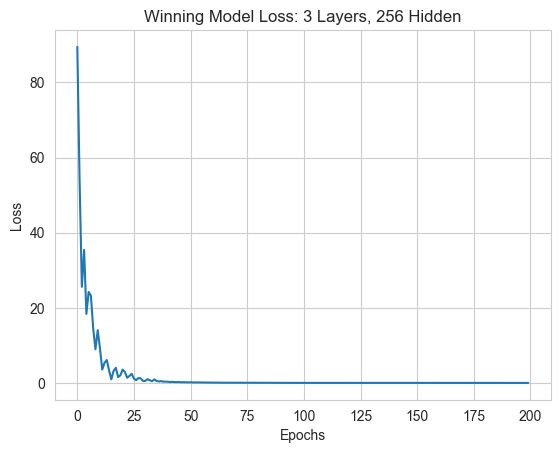

In [41]:
opt_layers, opt_hidden, best_loss, all_histories = optimize_model_capacity(
    data_generator, 
    train_size=10000, val_size=1000, 
    start_hidden=8, max_hidden=256, 
    start_layers=1, max_layers=5,
    rel_tolerance=0.05, n_epochs=200, 
    learning_rate=0.01
)

# Plotting the winning model's loss curve:
plt.plot(all_histories[(opt_layers, opt_hidden)])
plt.title(f"Winning Model Loss: {opt_layers} Layers, {opt_hidden} Hidden")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## 7.1.b

In [11]:
# Define a data generator for training following f(x) = 16x1^2 + x1x2 + 8x2^2 - x1 -x2 +ln(1+x1^2 + x2^2) where x= [x1, x2]
def data_generator(n_samples):
    m1, m2, m3 = [0.0, 0.0], [2.5, 2.5], [-2.5, -2.5]
    c = [[5.0, 0.0], [0.0, 5.0]] # inverse covariance matrix 
    
    # expression to generate: sum(exp(-0.5 * (x - m).T @ c @ (x - m))for each mean)
    x = torch.rand(n_samples, 2)  # Randomly generate n_samples of 2D input
    y = torch.zeros(n_samples, 1)  # Initialize targets to zero
    for m in [m1, m2, m3]:
        m_tensor = torch.tensor(m, dtype=torch.float32)
        c_tensor = torch.tensor(c, dtype=torch.float32)
        y += torch.exp(-0.5 * ((x - m_tensor) @ c_tensor * (x - m_tensor)).sum(dim=1, keepdim=True))
        y /= (2 * np.pi * np.sqrt(np.linalg.det(c)))
    return x, y  # Return inputs and targets as tensors

In [12]:
# test generator
x_test, y_test = data_generator(5)
print("Sample Inputs:\n", x_test)
print("Sample Targets:\n", y_test)

Sample Inputs:
 tensor([[0.3576, 0.2590],
        [0.3251, 0.3179],
        [0.3442, 0.2670],
        [0.3274, 0.1906],
        [0.3962, 0.9497]])
Sample Targets:
 tensor([[1.9807e-05],
        [1.9232e-05],
        [2.0069e-05],
        [2.2529e-05],
        [2.2847e-06]])
